# Trajectory Analysis across models for _Suo et. al._ with Bootstapped Subgraphs

In [1]:
0

0

In [2]:
%load_ext autoreload
%autoreload 2

In [300]:
import sys
working_directory = "/home/icb/kemal.inecik/work/codes/sctram"
sys.path.append(working_directory)

import logging
import itertools
import subprocess
import gc
import os
import time
import numpy as np
import pandas as pd
import networkx as nx
import scanpy as sc
import anndata as ad
from math import sqrt

sc.settings.verbose = 3

In [4]:
from sctram.api._lower_level import TrajectoryEvaluationAPI
from sctram.input import InputTrajectories
from sctram.generate.real import sc_suo_developmental_complete

2025-05-11 14:05:10.116 | INFO     | sctram.api._defaults_read:load_default_metrics:23 - Loaded default metrics from /home/icb/kemal.inecik/work/codes/sctram/sctram/api/_defaults.yaml
2025-05-11 14:05:10.116 | INFO     | sctram.api._defaults_read:load_default_metrics:79 - Default metrics YAML structure validated successfully.


In [268]:
# Important to have consistent figures across platforms

%matplotlib inline
%config InlineBackend.figure_format='retina'

import pickle
import matplotlib as mpl
from matplotlib import ticker
from networkx.drawing.nx_agraph import graphviz_layout
from matplotlib import gridspec
import matplotlib.pyplot as plt
import seaborn as sns
import colorcet as cc
from adjustText import adjust_text  
import matplotlib.patheffects as path_effects

_rcparams_path = os.path.join(working_directory, "reproducibility/figure_rcparams/rcparams.pickle")
with open(_rcparams_path, "rb") as file:
    _rcparams = pickle.load(file)
plt.rcParams.update(_rcparams)

Download the dataset and preliminary subsetting

In [6]:
dataset_dir = "/home/icb/kemal.inecik/lustre_workspace/temp_sctram_data"
helpers_directory = os.path.join(os.getcwd(), "helper")
logs_directory = os.path.join(os.getcwd(), "logs")

In [7]:
adata_suo_complete = sc_suo_developmental_complete(dataset_dir=dataset_dir)
display(adata_suo_complete)

2025-05-11 14:05:18.946 | WARNING  | sctram.generate.real._download:download_dataset:105 - File PosixPath('/home/icb/kemal.inecik/lustre_workspace/temp_sctram_data/suo_developmental_complete.h5ad') already exists. Skipping download.


AnnData object with n_obs × n_vars = 841922 × 8192
    obs: 'sample_ID', 'organ', 'age', 'cell_type', 'sex', 'sex_inferred', 'concatenated_integration_covariates', 'integration_donor', 'integration_biological_unit', 'integration_sample_status', 'integration_library_platform_coarse', 'n_genes', '_scvi_batch', '_scvi_labels', 'LVL3', 'LVL2', 'LVL1', 'LVL0'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'rank_genes_groups'
    obsm: 'Unintegrated', 'X_pca', 'harmony', 'invae', 'scanvi', 'scvi', 'tardis_1', 'tardis_2'

In [8]:
itpn_dict = {
    "adata_suo_input_haematopoeitic_lineage_litc_1.pkl": "1", 
    "adata_suo_input_haematopoeitic_lineage_litc_2.pkl": "2", 
    "adata_suo_input_haematopoeitic_lineage.pkl": "manual"
}

litc_dict = dict()
for itp in itpn_dict.keys():
    itp_path = os.path.join(dataset_dir, itp)
    with open(itp_path, "rb") as _file:
        litc_dict[itp] = pickle.load(_file)

# Running the `sctram` package

In [289]:
df = pd.DataFrame()

lineage = "Haematopoeitic_lineage"
lineage_part = lineage.replace("_lineage", "").lower()
for itp, itp_name in itpn_dict.items():

    litc = litc_dict[itp]
    decompose_method = itpn_dict[itp]
    
    for use_rep in adata_suo_complete.obsm.keys():
        if use_rep == "Unintegrated":
            continue

        for trajectory in sorted(litc.graph["trajectories"]):

            if decompose_method != "manual":
                output_file = os.path.join(dataset_dir, f"_metric_adata_suo_bootstrap_method_{decompose_method}_{lineage_part}_{use_rep}_{trajectory}.pickle")
            else:
                output_file = os.path.join(dataset_dir, f"_metric_adata_suo_{lineage_part}_{use_rep}_{trajectory}.pickle")
            
            if not os.path.exists(output_file) or not os.path.isfile(output_file):
                raise ValueError(f"Job {count+1!r} of {lineage!r} with {use_rep!r} of trajectory {trajectory!r} for method {decompose_method!r}")
            else:
                df_trajectory_obsm = pd.read_pickle(output_file)
                df_trajectory_obsm["bootstrapping_method"] = decompose_method if decompose_method == "manual" else f"method_{decompose_method}"
                df_trajectory_obsm["representation"] = use_rep
                df_trajectory_obsm["trajectory"] = trajectory
                df = pd.concat([df, df_trajectory_obsm])

df.reset_index(drop=True, inplace=True)
df['score'] = pd.to_numeric(df['score'], errors='raise')
df.sort_values(by=["bootstrapping_method", "trajectory", "path", "metric", "representation"], inplace=True, ignore_index=True)
df = df[["bootstrapping_method", "trajectory", "path", "metric", "representation", "score"]]

In [290]:
trajectory_classification_dict = {
    'alternative_myeloid': 'myeloid',
    'b_cell_specialization': 'lymphoid',
    'b_cells': 'lymphoid',
    'cd4': 'lymphoid',
    'complete_stem_trajectory': 'other',
    'dendritic': 'myeloid',
    'early_b_cells': 'lymphoid',
    'early_lymphoid': 'lymphoid',
    'early_stem_trajectory': 'other',
    'elp_branching': 'lymphoid',
    'erythroid': 'mem',
    'erythroid_megakaryocyte': 'mem',
    'gmp_branching': 'myeloid',
    'granulocyte_macrophage': 'myeloid',
    'granulocyte_mast': 'myeloid',
    'granulocyte_monocytes': 'myeloid',
    'haematopoeitic_lineage': 'other',
    'icl_nk': 'lymphoid',
    'macrophage_specialization': 'myeloid',
    'megakaryocyte': 'mem',
    'neutrophil': 'myeloid',
    'stem_cells_and_lymphoid_differentiated_cells': 'lymphoid',
    'stem_cells_and_mem': 'mem',
    'stem_cells_and_myeloid_differentiated_cells': 'myeloid',
    't_cell_mid': 'lymphoid',
    't_cell_nkt': 'lymphoid',
    'tissue_macrophages': 'myeloid'
}

metric_direction_dict = {
    # (lower is better)
    'frobenius': 'decreasing',
    'l1_norm': 'decreasing',
    'graph_edit_distance': 'decreasing',
    'spectral_distance': 'decreasing',
    'hamming_distance': 'decreasing',
    'average_shortest_path_difference': 'decreasing',
    'laplacian_spectral_emd': 'decreasing',
    'clustering_coeff_diff': 'decreasing',
    'weisfeiler_lehman_distance': 'decreasing',
    'maximum_common_subgraph_distance': 'decreasing',
    'random_walk_kernel_distance': 'decreasing',
    'persistence_diagram_distance': 'decreasing',
    'mse': 'decreasing',
    'mae': 'decreasing',
    'dtw_distance': 'decreasing',
    'wasserstein_distance_pseudotime': 'decreasing',
    'cdf_kolmogorov_smirnov': 'decreasing',
    'cdf_cramer_von_mises': 'decreasing',
    'sammons_stress': 'decreasing',
    'wasserstein_distance_embedding': 'decreasing',
    'gearys_c_embedding': 'decreasing',
    'gearys_c_pseudotime': 'decreasing',

    # (unsure)
    'normalized_mean_curvature': 'decreasing',
    
    # (higher is better)
    'accuracy': 'increasing',
    'jaccard_similarity': 'increasing',
    'recall': 'increasing',
    'precision': 'increasing',
    'f1_score': 'increasing',
    'permutation_marginalized_ssim': 'increasing',
    'mantel_correlation': 'increasing',
    'gdv_similarity': 'increasing',
    'gin_gnn_similarity': 'increasing',
    'pearson_correlation': 'increasing',
    'spearman_correlation': 'increasing',
    'kendall_correlation': 'increasing',
    'r_squared_with_spline': 'increasing',
    'r_squared': 'increasing',
    'concordance_index': 'increasing',
    'normalized_mutual_information': 'increasing',
    'mutual_information_kde': 'increasing',
    'branch_silhouette_score': 'increasing',
    'embedding_distance_correlation': 'increasing',
    'graph_based_trustworthiness': 'increasing',
    'neighborhood_preservation_score': 'increasing',
    'directionality_preservation': 'increasing',
    'trajectory_cardinality_validation': 'increasing',
    'morans_i_embedding': 'increasing',
    'morans_i_pseudotime': 'increasing'
}
assert set(df["metric"].unique()) == set(metric_direction_dict.keys())
df["trajectory_class"]= [trajectory_classification_dict.get(r["trajectory"], "NA") for _, r in df.iterrows()]
df = df[["bootstrapping_method", "trajectory", "trajectory_class", "path", "metric", "representation", "score"]]

In [291]:
def rank_metrics(df, metric_direction_dict, metric_index_pos, method='min'):
    ranked_df = pd.DataFrame(index=df.index, columns=df.columns, dtype=float)
    for indices, row in df.iterrows():
        
        metric = indices[metric_index_pos]
        direction = metric_direction_dict.get(metric)
        
        if direction not in ('increasing', 'decreasing'):
            raise ValueError            
        
        numeric_row = pd.to_numeric(row, errors='coerce')
        if numeric_row.isna().any():
            ranked_df.loc[indices] = np.nan
            continue
        
        if direction == 'increasing':
            ranks = numeric_row.rank(method='dense', ascending=False)
        else:
            ranks = numeric_row.rank(method='dense', ascending=True)

        # ranks = 1 - pd.Series(MinMaxScaler().fit_transform(row.values.reshape(-1, 1)).flatten(), index=row.index)
        
        ranked_df.loc[indices] = ranks.astype('Float64')
    return ranked_df

def rank_df(df, direction):
    ranked_df = pd.DataFrame(index=df.index, columns=df.columns, dtype=int)
    for indices, row in df.iterrows():
        numeric_row = pd.to_numeric(row, errors='raise')
        if direction == 'increasing':
            ranks = numeric_row.rank(method='dense', ascending=False)
        else:
            ranks = numeric_row.rank(method='dense', ascending=True)
        ranked_df.loc[indices] = ranks.astype('Int64')
    return ranked_df
    
def min_max_scaler(df):
    return pd.DataFrame(
        MinMaxScaler().fit_transform(df),
        columns=df.columns,
        index=df.index,
    )

def min_max_scaler_rowwise(df):
    def scale_row(row):
        if row.isna().any():  # If any NaN is present, return NaNs
            return pd.Series([np.nan] * len(row), index=row.index)
        return pd.Series(MinMaxScaler().fit_transform(row.values.reshape(-1, 1)).flatten(), index=row.index)
    return df.apply(scale_row, axis=1)

def min_max_scaler_rowwise_direction_aware(df, metric_direction_dict, metric_index_pos):
    ranked_df = pd.DataFrame(index=df.index, columns=df.columns, dtype=float)
    for indices, row in df.iterrows():
        metric = indices[metric_index_pos]
        
        direction = metric_direction_dict.get(metric)
        if direction not in ('increasing', 'decreasing'):
            raise ValueError
        
        numeric_row = pd.to_numeric(row, errors='coerce')
        if numeric_row.isna().any():
            ranked_df.loc[indices] = np.nan
            continue
        
        norm_row = pd.Series(MinMaxScaler().fit_transform(numeric_row.values.reshape(-1, 1)).flatten(), index=numeric_row.index)
        if direction == 'increasing':
            adjusted_row = norm_row
        else:
            adjusted_row = 1 - norm_row
        ranked_df.loc[indices] = adjusted_row.astype('Float64')
    return ranked_df

## Analysis

In [292]:
df

,bootstrapping_method,trajectory,trajectory_class,path,metric,representation,score
0,manual,alternative_myeloid,myeloid,adjacency,accuracy,X_pca,0.920000
1,manual,alternative_myeloid,myeloid,adjacency,accuracy,harmony,0.920000
2,manual,alternative_myeloid,myeloid,adjacency,accuracy,invae,0.920000
3,manual,alternative_myeloid,myeloid,adjacency,accuracy,scanvi,0.760000
4,manual,alternative_myeloid,myeloid,adjacency,accuracy,scvi,0.920000
...,...,...,...,...,...,...,...
56443,method_2,haematopoeitic_lineage_subgraph_99,NA,pseudotime,wasserstein_distance_pseudotime,invae,0.335305
56444,method_2,haematopoeitic_lineage_subgraph_99,NA,pseudotime,wasserstein_distance_pseudotime,scanvi,0.206439
56445,method_2,haematopoeitic_lineage_subgraph_99,NA,pseudotime,wasserstein_distance_pseudotime,scvi,0.360832
56446,method_2,haematopoeitic_lineage_subgraph_99,NA,pseudotime,wasserstein_distance_pseudotime,tardis_1,0.301917


In [293]:
df_bs = df[df["bootstrapping_method"] == "method_2"]
lit = litc_dict['adata_suo_input_haematopoeitic_lineage_litc_2.pkl']
len(df_bs)

38304

In [295]:
df_pivot = df_bs.pivot(index=['trajectory_class', 'trajectory', 'path', 'metric'], columns='representation', values='score')
df_pivot_rank = rank_metrics(df_pivot, metric_direction_dict, metric_index_pos=3, method='min')
df_rank = df_pivot_rank.reset_index(drop=False, inplace=False).copy()
df_pivot_rank

representation                                                                                   X_pca  \
trajectory_class trajectory                         path       metric                                    
NA               haematopoeitic_lineage_subgraph_0  adjacency  accuracy                            2.0   
                                                               average_shortest_path_difference    6.0   
                                                               clustering_coeff_diff               2.0   
                                                               f1_score                            2.0   
                                                               frobenius                           3.0   
...                                                                                                ...   
                 haematopoeitic_lineage_subgraph_99 pseudotime pearson_correlation                 2.0   
                                                               r_squared                           1.0   
                                                               r_squared_with_spline               3.0   
                                                               spearman_correlation                5.0   
                                                               wasserstein_distance_pseudotime     1.0   

representation                                                                                   harmony  \
trajectory_class trajectory                         path       metric                                      
NA               haematopoeitic_lineage_subgraph_0  adjacency  accuracy                              1.0   
                                                               average_shortest_path_difference      3.0   
                                                               clustering_coeff_diff                 4.0   
                                                               f1_score                              1.0   
                                                               frobenius                             1.0   
...                                                                                                  ...   
                 haematopoeitic_lineage_subgraph_99 pseudotime pearson_correlation                   5.0   
                                                               r_squared                             7.0   
                                                               r_squared_with_spline                 6.0   
                                                               spearman_correlation                  7.0   
                                                               wasserstein_distance_pseudotime       7.0   

representation                                                                                   invae  \
trajectory_class trajectory                         path       metric                                    
NA               haematopoeitic_lineage_subgraph_0  adjacency  accuracy                            1.0   
                                                               average_shortest_path_difference    5.0   
                                                               clustering_coeff_diff               3.0   
                                                               f1_score                            1.0   
                                                               frobenius                           2.0   
...                                                                                                ...   
                 haematopoeitic_lineage_subgraph_99 pseudotime pearson_correlation                 7.0   
                                                               r_squared                           4.0   
                                                               r_squared_with_spline               7.0   
                                                  

In [28]:
df_edges = []
for ind, row in df_bs.iterrows():
    trj = lit.get_trajectory(row["trajectory"], False)
    for from_cell, to_cell in trj.edges():
        row_copy = row.copy()
        row_copy["from_cell"] = from_cell
        row_copy["to_cell"] = to_cell
        df_edges.append(row_copy)
df_edges = pd.DataFrame(df_edges)
df_edges.reset_index(drop=True, inplace=True)

In [29]:
df_edges_pivot = df_edges.pivot(index=['path', 'trajectory', 'trajectory_class', 'metric', 'from_cell', 'to_cell'], columns='representation', values='score')
df_edges_pivot_rank = rank_metrics(df_edges_pivot, metric_direction_dict, metric_index_pos=3, method='min')

df_edges_pivot_rank_mean = df_edges_pivot_rank.groupby(level=[4, 5]).mean()
df_edges_pivot_rank_mean

representation                       X_pca   harmony     invae    scanvi  \
from_cell     to_cell                                                      
CD4 T         Regulatory T cells  3.771883  5.042440  3.557029  2.960212   
              Th17                3.816976  5.010610  3.633952  2.877984   
CD5- mature B B1 cells            3.658363  4.362989  3.530249  2.793594   
              Plasma B cells      3.779359  4.395018  3.455516  2.854093   
CD8 T         CD8AA               3.824773  5.132931  3.664653  2.885196   
...                                    ...       ...       ...       ...   
Small pre-B   Immature B          3.245783  4.534940  3.491566  3.130120   
Tab(entry)    CD4 T               3.550321  4.869379  3.535332  3.109208   
              CD8 T               3.755319  4.933511  3.614362  2.962766   
              Cycling T           3.595166  5.051360  3.667674  3.018127   
pDC           Cycling pDC         3.400000  4.165957  3.221277  2.940426   

representation                        scvi  tardis_1  tardis_2  
from_cell     to_cell                                           
CD4 T         Regulatory T cells  3.901857  3.872679  3.137931  
              Th17                3.798408  3.864721  3.084881  
CD5- mature B B1 cells            4.110320  3.793594  3.064057  
              Plasma B cells      4.042705  3.996441  3.163701  
CD8 T         CD8AA               4.120846  3.924471  3.090634  
...                                    ...       ...       ...  
Small pre-B   Immature B          3.893976  3.742169  2.792771  
Tab(entry)    CD4 T               3.732334  3.858672  3.158458  
              CD8 T               3.944149  3.835106  3.058511  
              Cycling T           3.891239  3.939577  3.072508  
pDC           Cycling pDC         4.242553  4.242553  3.391489  

[66 rows x 7 columns]

In [30]:
trj = litc_dict['adata_suo_input_haematopoeitic_lineage.pkl'].get_trajectory("haematopoeitic_lineage", False).copy()
for (from_cell, to_cell), representations in df_edges_pivot_rank_mean.iterrows():
    for representation, score in representations.items():
        trj[from_cell][to_cell][f"weight_{representation}"] = score

In [31]:
list(trj[from_cell][to_cell].keys())

['weight_X_pca',
 'weight_harmony',
 'weight_invae',
 'weight_scanvi',
 'weight_scvi',
 'weight_tardis_1',
 'weight_tardis_2']

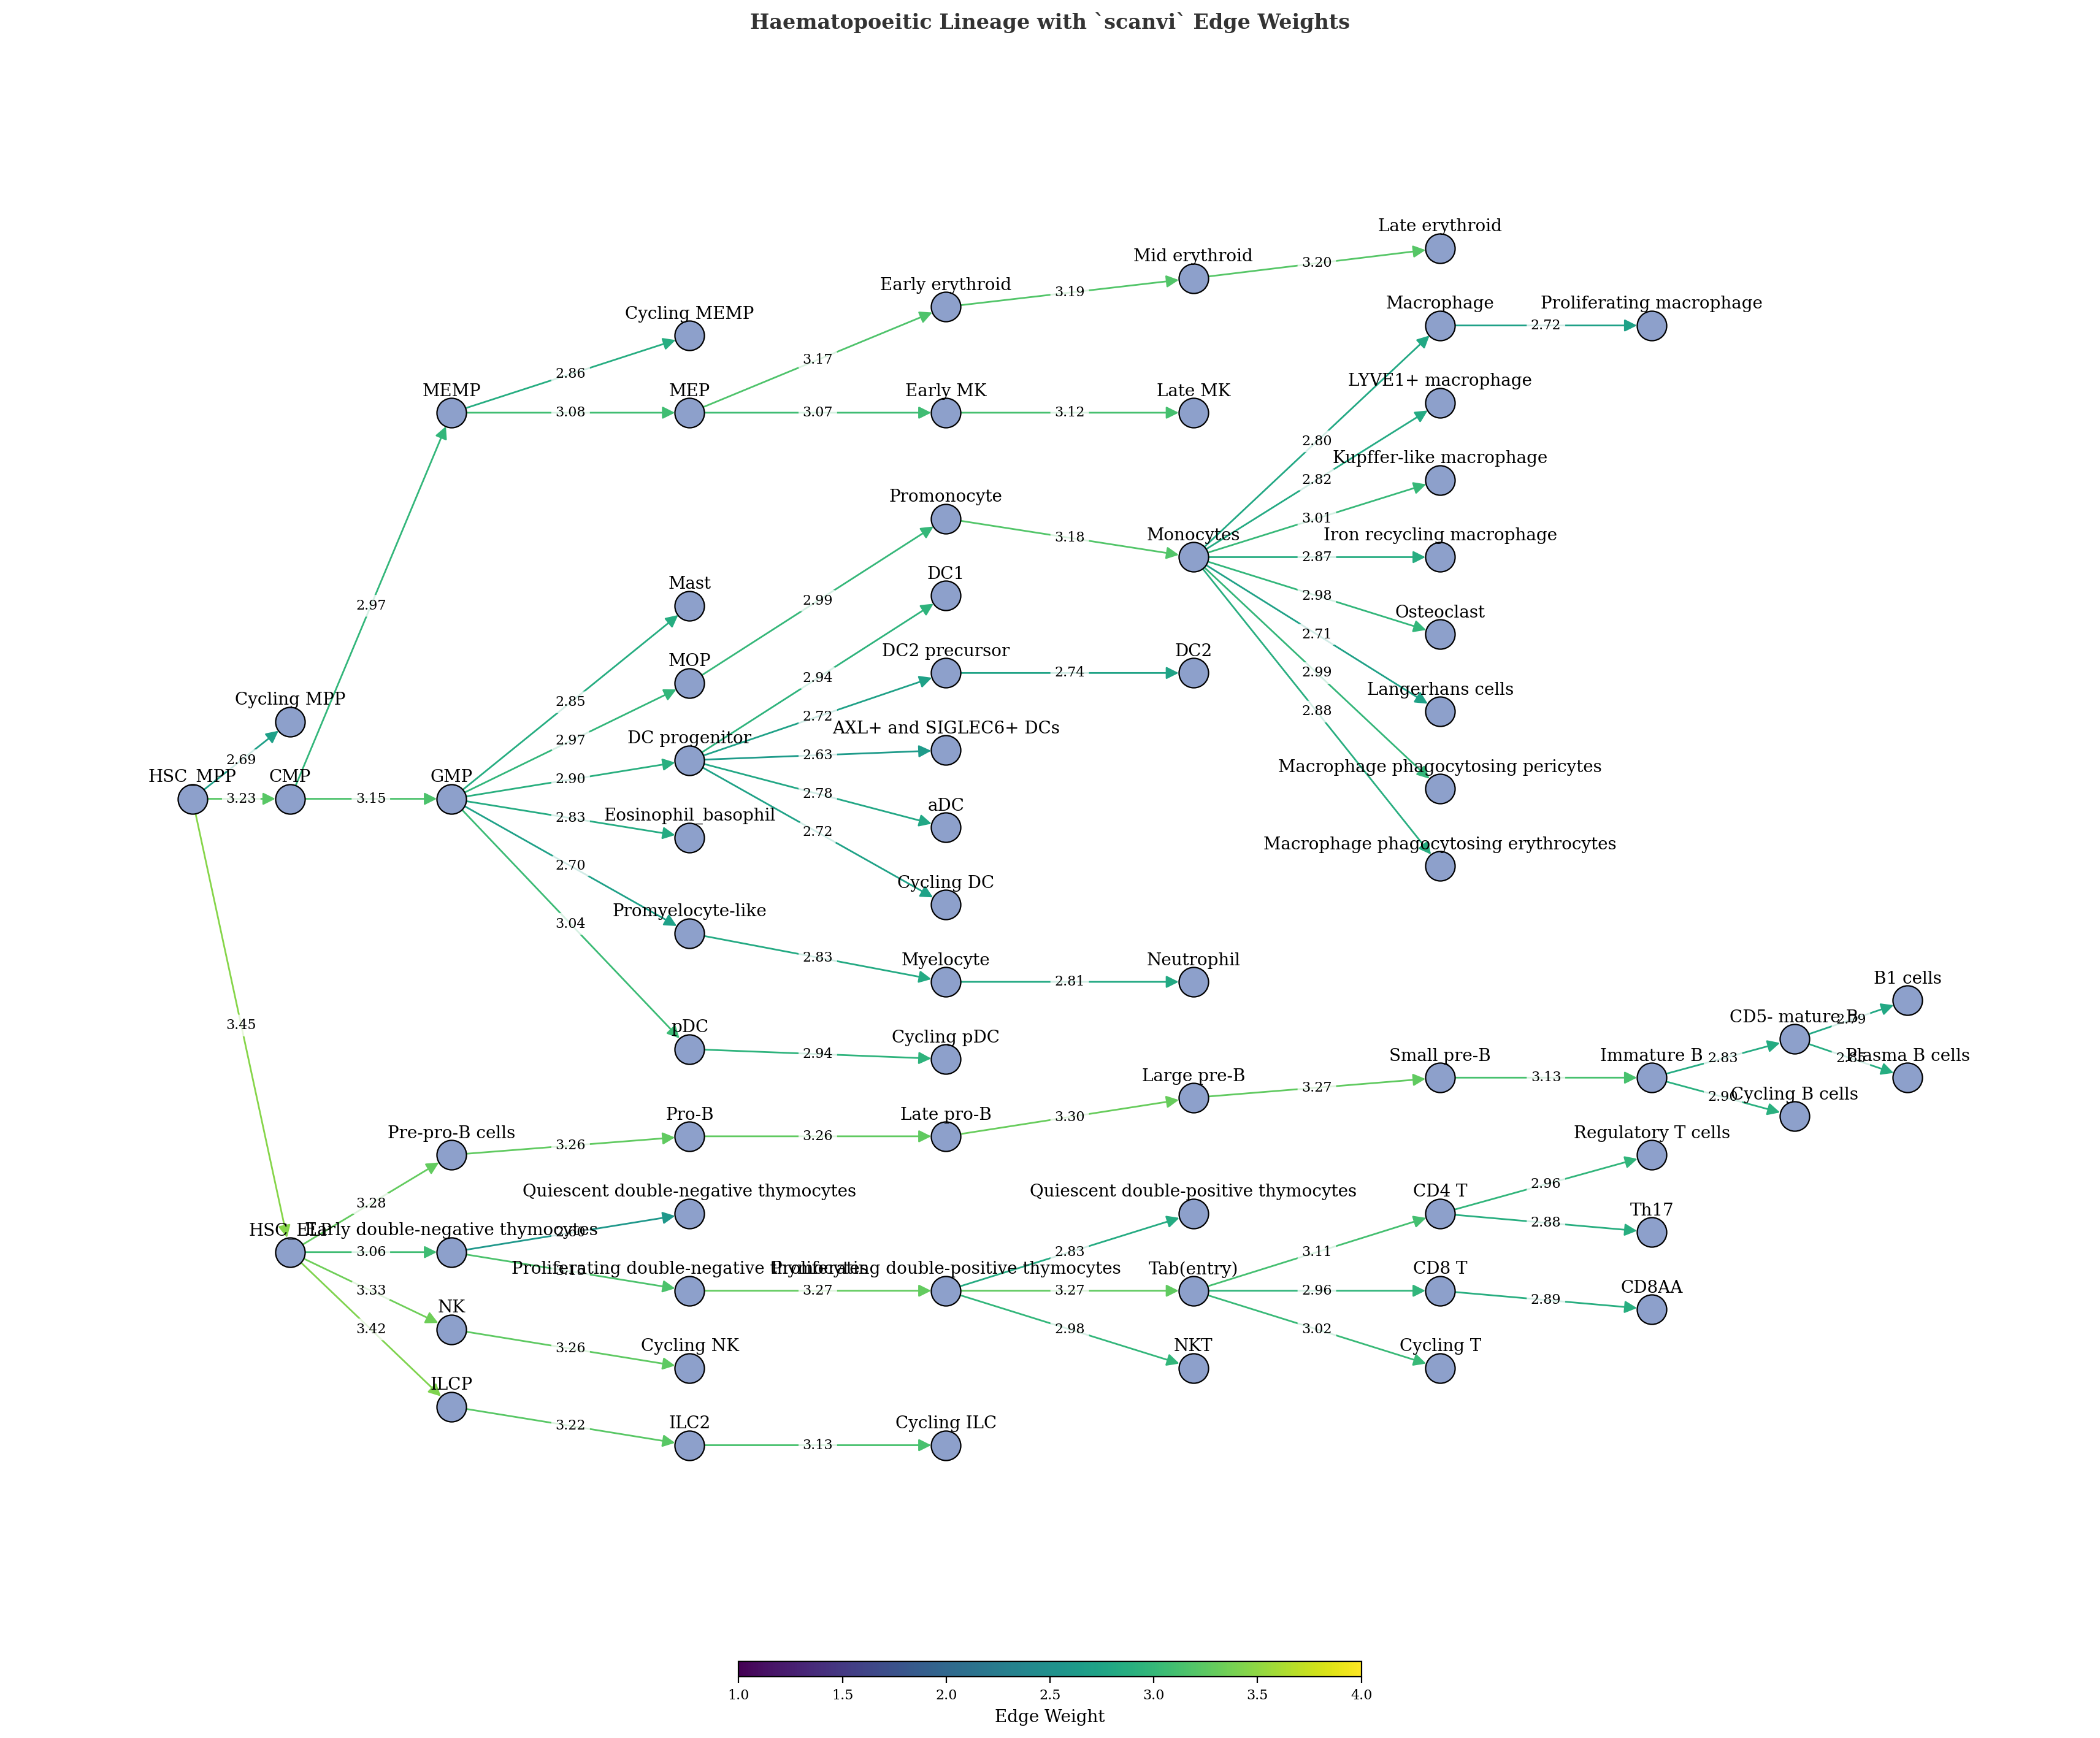

In [37]:
trj.plot_trajectory(
    title="Haematopoeitic Lineage with `scanvi` Edge Weights",
    figsize=(18, 18), 
    label_offset=15,
    color_edges_by_weight=True,
    edge_weight_attribute="weight_scanvi",
    edge_labels=True,
    edge_colorbar=True,
    edge_vmin=1,
    edge_vmax=4,
    edge_cmap='viridis'
)

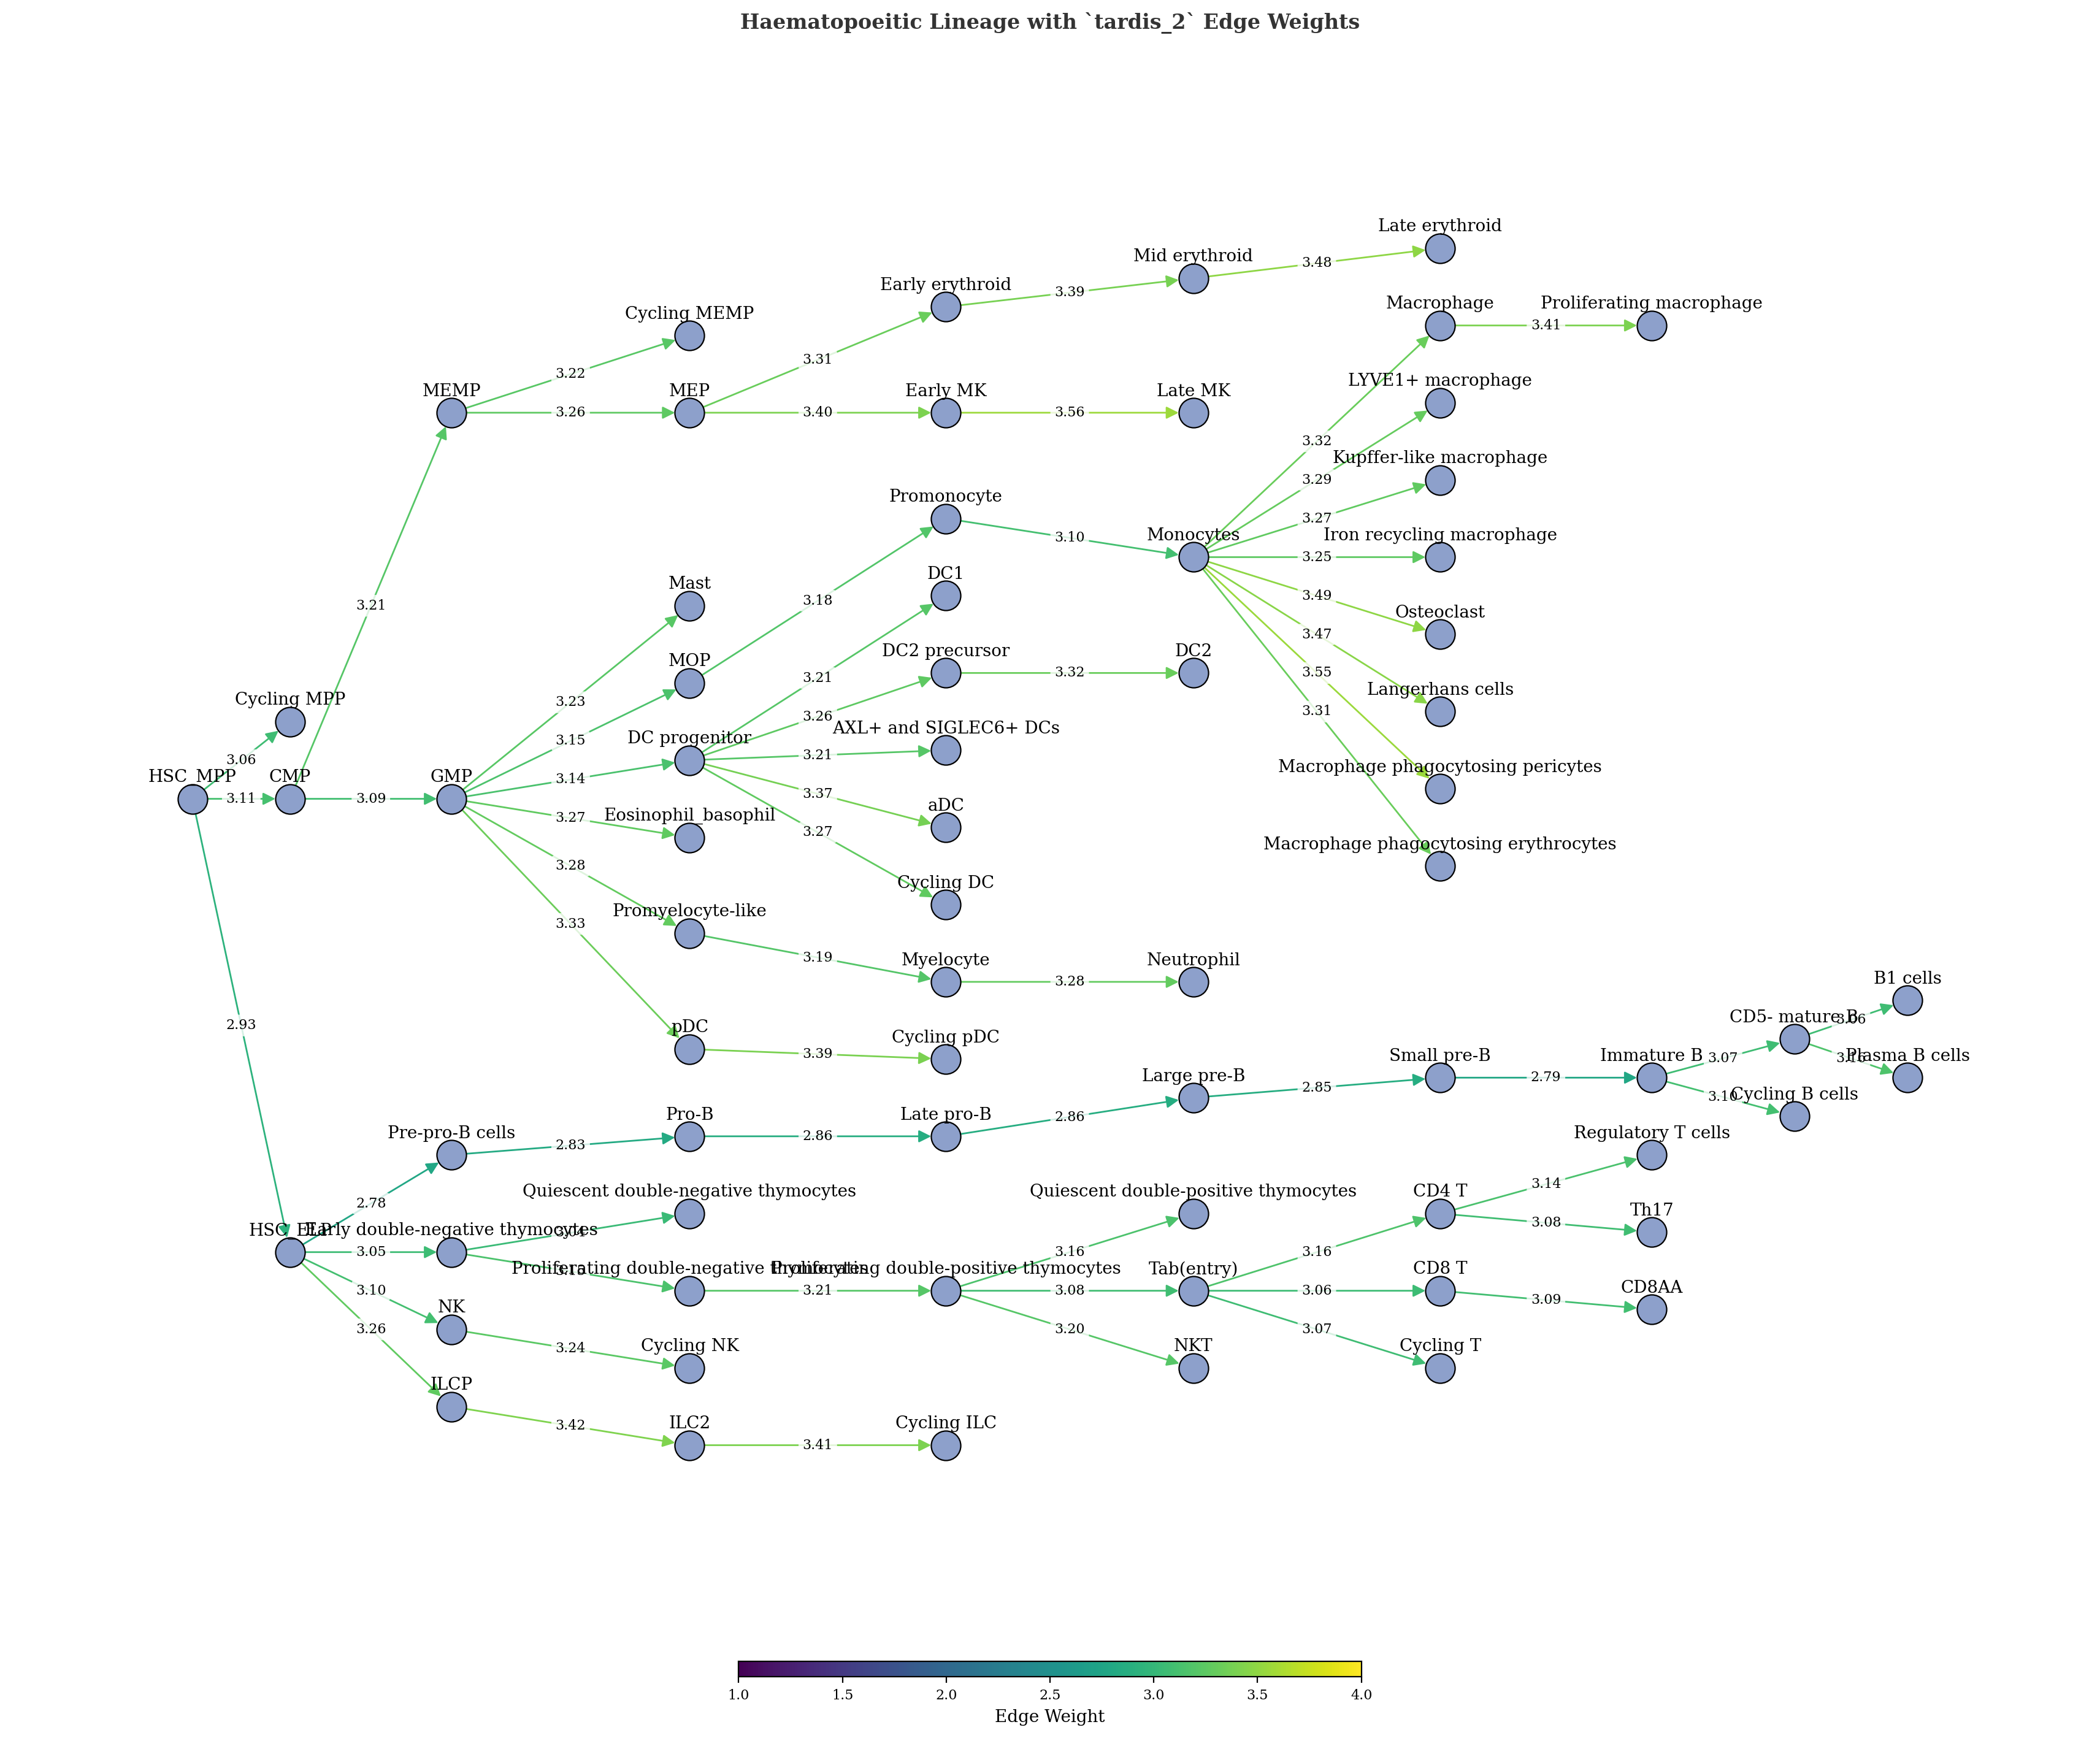

In [34]:
trj.plot_trajectory(
    title="Haematopoeitic Lineage with `tardis_2` Edge Weights",
    figsize=(18, 18), 
    label_offset=15,
    color_edges_by_weight=True,
    edge_weight_attribute="weight_tardis_2",
    edge_labels=True,
    edge_colorbar=True,
    edge_vmin=1,
    edge_vmax=4,
    edge_cmap='viridis'
)

In [220]:
def plot_trajectory(
    G,
    title="trajectory_name",
    figsize=None,
    font_size=10,
    node_size=300,
    node_color="#8DA0CB",  # Modern muted blue
    cmap="viridis",
    color_nodes_by_position=False,
    # Edge styling parameters
    edge_width=1,
    edge_color="gray",
    color_edges_by_weight=False,
    edge_weight_attribute="weight",
    edge_cmap="plasma",
    edge_vmin=None,
    edge_vmax=None,
    edge_colorbar=True,
    edge_labels=False,
    edge_label_format=".2f",
    edge_label_font_size=8,
    edge_label_color="black",
    edge_label_offset=None,
    # Layout parameters
    label_offset=None,
    title_y=1.02,
    layout_args="-Grankdir=LR -Gnodesep=0.25 -Granksep=0.25",
):
    
    pos = nx.nx_agraph.graphviz_layout(G, prog="dot", args=layout_args)
    x_coords = [pos[node][0] for node in G.nodes()] if G.nodes() else []
    y_coords = [pos[node][1] for node in G.nodes()] if G.nodes() else []

    # Create actual figure with determined size
    fig = plt.figure(figsize=figsize)
    ax = fig.add_subplot(111)

    # Node coloring logic
    if color_nodes_by_position:
        try:
            min_x, max_x = min(x_coords), max(x_coords)
            color_vals = [(x - min_x) / (max_x - min_x) if max_x != min_x else 0.5 for x in x_coords]
            node_color = plt.get_cmap(cmap)(color_vals)
        except Exception as e:
            print(f"Warning: Positional node coloring failed - {e}. Using base color.")

    # Edge coloring logic
    if color_edges_by_weight:
        weights = [G[u][v].get(edge_weight_attribute, 1.0) for u, v in G.edges]
        edge_vmin = edge_vmin if edge_vmin is not None else (min(weights) if weights else 0)
        edge_vmax = edge_vmax if edge_vmax is not None else (max(weights) if weights else 1)
        norm = mpl.colors.Normalize(vmin=edge_vmin, vmax=edge_vmax)
        cmap_edge = plt.get_cmap(edge_cmap)
        edge_colors = [cmap_edge(norm(w)) for w in weights]
        sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap_edge)
        sm.set_array(weights)
    else:
        edge_colors = edge_color
        sm = None

    # Label positioning offsets
    if label_offset is None:
        label_offset = 0

    if edge_label_offset is None:
        edge_label_offset = 0

    # Calculate final label positions
    label_pos = {n: (x, y + label_offset) for n, (x, y) in pos.items()}

    # Draw nodes and edges
    nx.draw_networkx_nodes(
        G, pos, ax=ax, node_size=node_size, node_color=node_color, edgecolors="black", linewidths=0.8, alpha=1.0
    )

    node_radius = sqrt(node_size) / 2.0
    
    nx.draw_networkx_edges(
        G,
        pos,
        ax=ax,
        # arrowstyle="-|>",
        # arrowsize=4,
        edge_color=edge_colors,
        width=edge_width,
        alpha=1.0,
        connectionstyle="arc3",
        arrows=False,  
        # # chop off exactly one node‐radius at each end
        # min_source_margin=node_radius,
        # min_target_margin=node_radius,
    )

    # Edge label placement
    if edge_labels:
        for u, v in G.edges():
            if edge_weight_attribute not in G[u][v]:
                continue
            weight = G[u][v][edge_weight_attribute]
            x1, y1 = pos[u]
            x2, y2 = pos[v]
            dx, dy = x2 - x1, y2 - y1
            length = (dx**2 + dy**2) ** 0.5
            if length == 0:
                continue  # Skip self-loops
            # Calculate perpendicular offset position
            mid_x = (x1 + x2) / 2 + (dy / length) * edge_label_offset
            mid_y = (y1 + y2) / 2 - (dx / length) * edge_label_offset
            ax.text(
                mid_x,
                mid_y,
                f"{weight:{edge_label_format}}",
                fontsize=edge_label_font_size,
                color=edge_label_color,
                ha="center",
                va="center",
                # bbox=dict(boxstyle="round", facecolor="white", alpha=0.8, edgecolor="none"),
            )

    # Edge weight colorbar
    if color_edges_by_weight and edge_colorbar and sm:
        cbar = plt.colorbar(sm, ax=ax, orientation="horizontal", shrink=0.3, aspect=40, pad=0.05)
        cbar.set_label("Edge Weight", fontsize=font_size)
        cbar.ax.tick_params(labelsize=font_size - 2)

    fig.suptitle(title, y=title_y, fontsize=font_size + 2, fontweight="bold", color="#333333")

    # Final layout adjustments
    plt.subplots_adjust(
        left=0.03, right=0.97, top=0.97, bottom=0.15 if (color_edges_by_weight and edge_colorbar) else 0.03
    )
    ax.set_axis_off()
    plt.show()

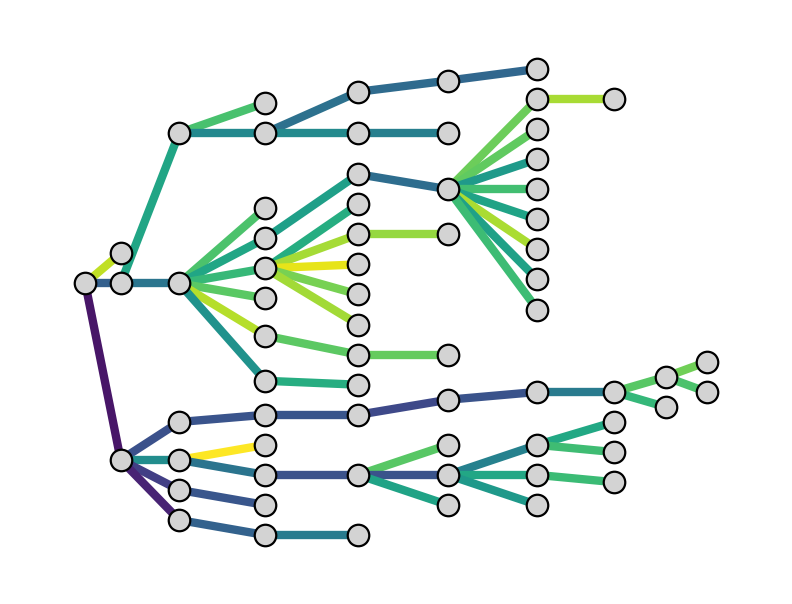

In [252]:
plot_trajectory(
    trj, 
    figsize=(4, 3),
    edge_weight_attribute="weight_scanvi",
    title=None, 
    edge_vmin=2.6,
    edge_vmax=3.5,
    color_edges_by_weight=True, 
    node_size=60, 
    node_color="lightgray", 
    edge_color='black',
    edge_width=3,
    edge_labels=False,
    edge_label_font_size=5,
    edge_cmap='viridis_r',
    edge_colorbar=False
)

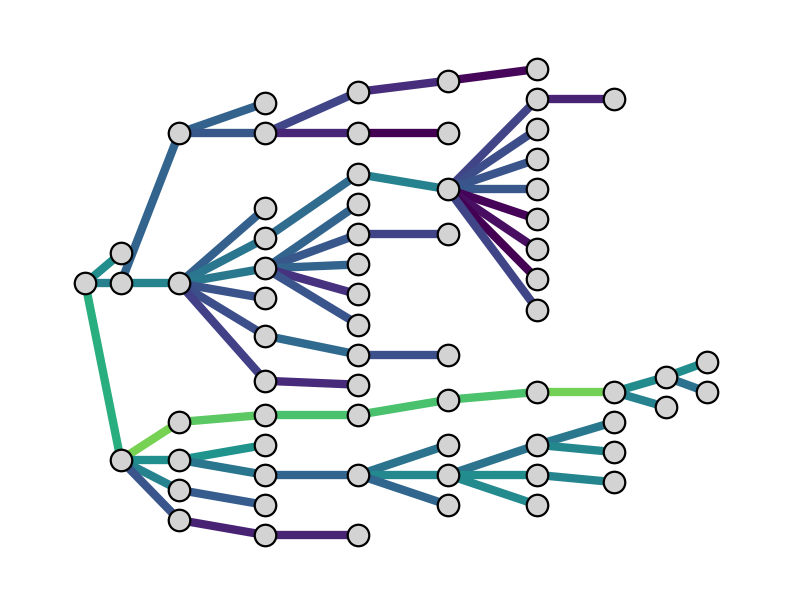

In [251]:
plot_trajectory(
    trj, 
    figsize=(4, 3),
    edge_weight_attribute="weight_tardis_2",
    title=None, 
    edge_vmin=2.6,
    edge_vmax=3.5,
    color_edges_by_weight=True, 
    node_size=60, 
    node_color="lightgray", 
    edge_color='black',
    edge_width=3,
    edge_labels=False,
    edge_label_font_size=5,
    edge_cmap='viridis_r',
    edge_colorbar=False
)

In [284]:
def create_vertical_colorbar(
    label,
    vmin=2.5,
    vmax=3.5,
    cmap='plasma',
    fontsize=10,
    n_ticks=5,
    fig_height=4,
    fig_width=1,
    scale=1.0
):
    """
    Creates and displays a standalone vertical colorbar.

    Parameters:
    - label:        str, label for the colorbar
    - vmin, vmax:   float, data range
    - cmap:         str, colormap name
    - fontsize:     int, for label & tick labels
    - n_ticks:      int, approx number of ticks to show
    - fig_height:   float, base height in inches
    - fig_width:    float, base width in inches
    - scale:        float, scale factor for overall size
    """
    # 1) Make the ScalarMappable
    norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
    sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])

    # 2) New figure, scaled
    fig = plt.figure(figsize=(fig_width * scale, fig_height * scale))
    # you can tweak these numbers if you want more/less padding
    cax = fig.add_axes([0.2, 0.05, 0.3, 0.9])

    # 3) Draw the colorbar
    cbar = fig.colorbar(
        sm,
        cax=cax,
        orientation='vertical'
    )

    # 4) Automatic “nice” locators + re‐draw
    cbar.locator = ticker.MaxNLocator(nbins=n_ticks)
    cbar.update_ticks()

    # 5) Force one‐decimal formatting
    cbar.ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f'))

    # 6) Label & style
    cbar.set_label(label, fontsize=fontsize)
    cbar.ax.tick_params(labelsize=fontsize)

    plt.show()

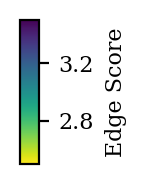

In [288]:
create_vertical_colorbar('Edge Score', cmap="viridis_r", n_ticks=3, fig_height=1, fig_width=0.4, scale=0.8, fontsize=8)

In [ ]:
trj.plot_trajectory(
    figsize=(18, 10),
    edge_weight_attribute="weight_scanvi",
    title=None, 
    color_edges_by_weight=False, 
    node_size=300, 
    node_color="lightgray", 
    edge_color='black',
    edge_width=1,
    edge_labels=True,
    edge_label_font_size=10,
    edge_colorbar=False,
    label_offset=18
)

In [ ]:
trj.plot_trajectory(
    figsize=(18, 10),
    edge_weight_attribute="weight_tardis_2",
    title=None, 
    color_edges_by_weight=False, 
    node_size=300, 
    node_color="lightgray", 
    edge_color='black',
    edge_width=1,
    edge_labels=True,
    edge_label_font_size=10,
    edge_colorbar=False,
    label_offset=18
)

# Correlated Metrics

In [296]:
df_rank_melt = df_rank.melt(
    id_vars=['trajectory_class', 'trajectory', 'path', 'metric'], 
    value_vars=['X_pca', 'harmony', 'invae', 'scanvi', 'scvi', 'tardis_1', 'tardis_2'],
    var_name='representation', 
    value_name='score'
)

In [297]:
df_rank_melt

,trajectory_class,trajectory,path,metric,representation,score
0,NA,haematopoeitic_lineage_subgraph_0,adjacency,accuracy,X_pca,2.0
1,NA,haematopoeitic_lineage_subgraph_0,adjacency,average_shortest_path_difference,X_pca,6.0
2,NA,haematopoeitic_lineage_subgraph_0,adjacency,clustering_coeff_diff,X_pca,2.0
3,NA,haematopoeitic_lineage_subgraph_0,adjacency,f1_score,X_pca,2.0
4,NA,haematopoeitic_lineage_subgraph_0,adjacency,frobenius,X_pca,3.0
...,...,...,...,...,...,...
38299,NA,haematopoeitic_lineage_subgraph_99,pseudotime,pearson_correlation,tardis_2,4.0
38300,NA,haematopoeitic_lineage_subgraph_99,pseudotime,r_squared,tardis_2,6.0
38301,NA,haematopoeitic_lineage_subgraph_99,pseudotime,r_squared_with_spline,tardis_2,4.0
38302,NA,haematopoeitic_lineage_subgraph_99,pseudotime,spearman_correlation,tardis_2,3.0


In [303]:
import logging
import subprocess
import gc
import os
import time
import numpy as np
import pandas as pd
import networkx as nx
import scanpy as sc
import anndata as ad
from sklearn.preprocessing import MinMaxScaler
from scipy.cluster.hierarchy import linkage, leaves_list
import scipy.stats as stats
import itertools

In [304]:
metrics = sorted(df_rank_melt["metric"].unique())
pairs = itertools.permutations(metrics, 2)
results = []
for col1, col2 in pairs:
    metric_1_values = df_rank_melt["score"][df_rank_melt["metric"] == col1].values.copy()
    metric_2_values = df_rank_melt["score"][df_rank_melt["metric"] == col2].values.copy()
    mask = pd.isna(metric_2_values) | pd.isna(metric_1_values)
    stat, p_value = stats.spearmanr(metric_1_values[~mask], metric_2_values[~mask])
    results.append((col1, col2, stat, p_value))
results_df = pd.DataFrame(results, columns=['Column 1', 'Column 2', 'Statistic', 'P-Value'])

In [305]:
results_df_pivot = results_df.pivot(index='Column 1', columns='Column 2', values='Statistic')
values_array = results_df_pivot.to_numpy()
np.fill_diagonal(values_array, 1.0)
results_df_pivot.loc[:, :] = values_array
results_df_pivot = results_df_pivot[results_df_pivot.index].round(3)

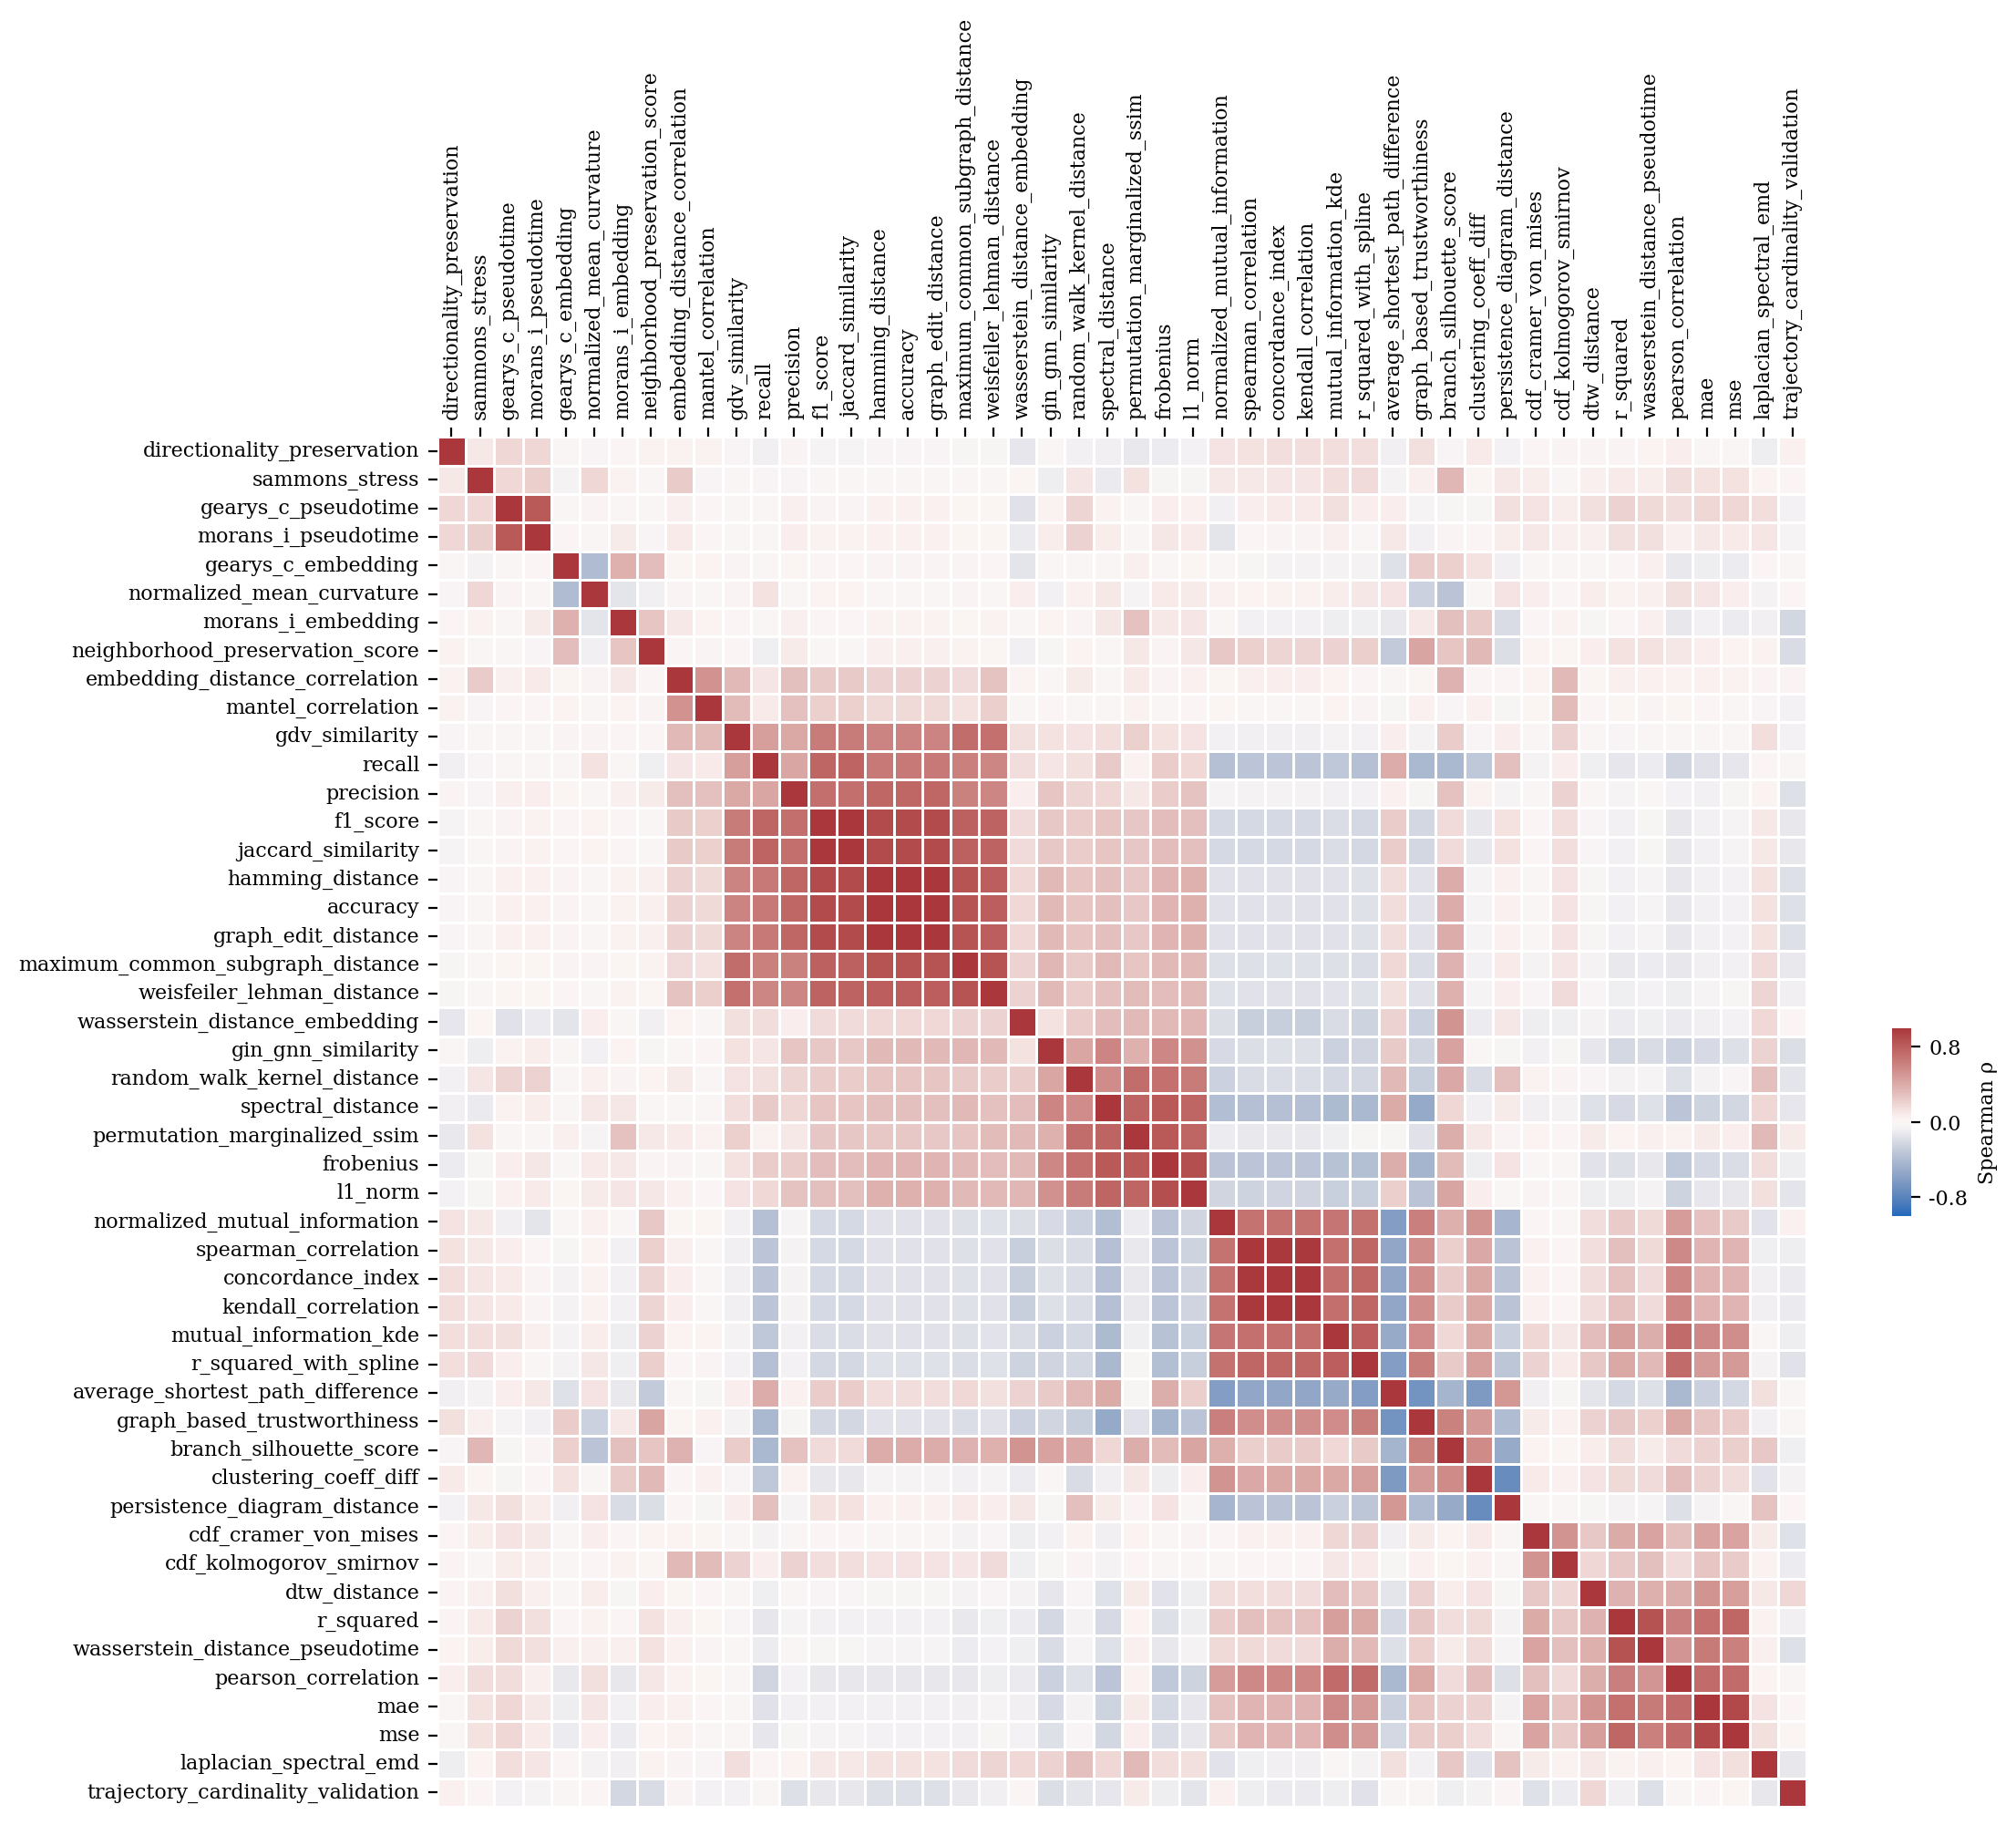

In [329]:
import numpy as np
from scipy.spatial.distance import squareform
from scipy.cluster.hierarchy import linkage, leaves_list

# Convert correlation matrix to distance matrix (preserving magnitude)
corr_matrix = results_df_pivot.values
distance_matrix = 1 - np.abs(corr_matrix)  # Focus on correlation magnitude

# Convert to condensed form and compute linkage
condensed_dist = squareform(distance_matrix)
linkage_matrix = linkage(condensed_dist, 
                        method='average',  # Better for correlation structures
                        metric='precomputed')

# Get optimal leaf ordering
cluster_order = leaves_list(linkage_matrix)

# Create clustered matrix
clustered_matrix = results_df_pivot.iloc[cluster_order, cluster_order]

# Create optimized heatmap
plt.figure(figsize=(12, 12))
ax = sns.heatmap(
    clustered_matrix,
    square=True,
    cmap='vlag',  # Diverging colormap with zero-center
    center=0,      # Explicit zero-center for correlations
    linewidths=0.5,
    linecolor='white',
    cbar_kws={
        "shrink": 0.1,
        "aspect": 10,      # lower aspect → thicker bar
        "location": "right",
        # "label": "Spearman ρ",
    },
    rasterized=True,
    vmin=-1,      # Explicit scale limits
    vmax=1
)


cbar = ax.collections[0].colorbar
cbar.locator = ticker.MaxNLocator(nbins=3)
cbar.update_ticks()
cbar.ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f'))
cbar.set_label("Spearman ρ", fontsize=8)
cbar.ax.tick_params(labelsize=8)

ax.set_xlabel("")
ax.set_ylabel("")

# Enhanced annotations
ax.xaxis.tick_top()
plt.xticks(rotation=90, fontsize=8, ha='center', va='bottom')
plt.yticks(rotation=0, fontsize=8, ha='right', va='center')

plt.box(False)
plt.tight_layout()
plt.show()